# Lecture 4 Exercises

In [ ]:
s

## Exercise 2.16

a) Verify by simulation that $\frac{n_{1} + n_{2} - 2 }{\sigma^{2}} S^{2}_{p}   \sim \chi^{2} (n_{1} + n_{2} -2)$ Use $ n_{1} = 5, n_{2} = 8, \mu_{1} = 2, \mu_{2} = 4$ and $\sigma^{2} = 2$

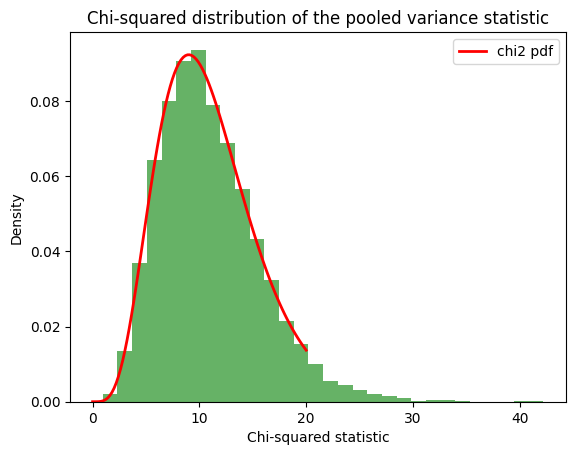

In [4]:
sim_size = 10_000
n_1, n_2 = 5, 8
mu_1, mu_2 = 2, 4
sigma2 = 2

chi2_stats = np.zeros(sim_size)

for i in range(sim_size):
    X = stats.norm.rvs(mu_1, np.sqrt(sigma2), n_1)
    Y = stats.norm.rvs(mu_2, np.sqrt(sigma2), n_2)

    S1_sq = np.var(X, ddof=1)
    S2_sq = np.var(Y, ddof=1)

    Sp_sq = ((n_1-1)*S1_sq + (n_2-1)*S2_sq) / (n_1+n_2 - 2)

    chi2_stats[i] = (n_1+n_2 -2)*Sp_sq/sigma2

plt.hist(chi2_stats, bins=30, density=True, alpha=0.6, color='g')
x = np.linspace(0, 20, 100)
plt.plot(x, stats.chi2.pdf(x, df=n_1+n_2-2), 'r-', lw=2, label='chi2 pdf')
plt.title('Chi-squared distribution of the pooled variance statistic')
plt.xlabel('Chi-squared statistic')
plt.ylabel('Density')
plt.legend()
plt.show()

b) Show that if $X \sim N(\mu_{1}, \sigma^{2})$ and $Y \sim N(\mu_{2}, \sigma^{2})$ then

$$ \frac{\overline{X} - \overline{Y} - (\mu_{1} - \mu_{2}) }{S_{p} \sqrt{\frac{1}{n_{1}} + \frac{1}{n_{2}}  } } \sim t (n_{1} + n_{2} -2) $$

Verify the result by simulation. You may use $n_{1} = 5, n_{2} = 8, \mu_{1} = 2, \mu_{2} = 4, \text{and } \sigma^{2} = 2$

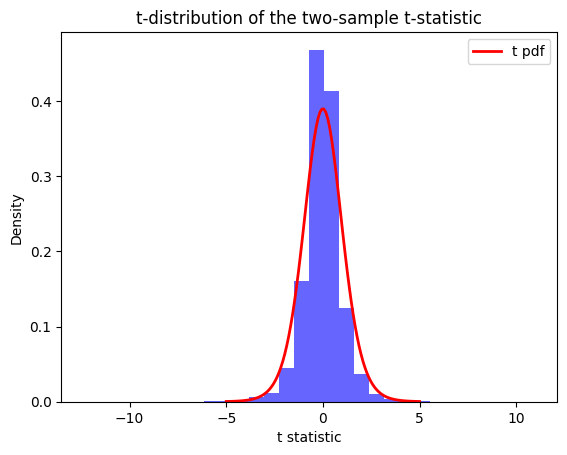

In [9]:

t_stats = np.zeros(sim_size)

for i in range(sim_size): 
    X = stats.norm.rvs(mu_1, np.sqrt(sigma2), n_1)
    Y = stats.norm.rvs(mu_2, np.sqrt(sigma2), n_2)

    X_mean = X.mean()
    Y_mean = Y.mean()

    S1_sq = np.var(X, ddof=1)
    S2_sq = np.var(Y, ddof=1)

    Sp_sq = ((n_1-1)*S1_sq + (n_2-1)*S2_sq) / (n_1+n_2 - 2)

    t_stats[i] = (X_mean - Y_mean - (mu_1 - mu_2 )) / (Sp_sq * np.sqrt(1/n_1 + 1/n_2 ))
    

plt.hist(t_stats, bins=30, density=True, alpha=0.6, color='b')
x = np.linspace(-5, 5, 100)
plt.plot(x, stats.t.pdf(x, df=n_1+n_2-2), 'r-', lw=2, label='t pdf')
plt.title('t-distribution of the two-sample t-statistic')
plt.xlabel('t statistic')
plt.ylabel('Density')
plt.legend()
plt.show()

## Exercise 2.17


a) 

In [22]:
n_arr = np.array([2,4,8,16,32])

for n in n_arr:
    df = n - 1
    print(f"n={n}:")
    print(f"  P(Q < 1)       = {stats.f.cdf(1,   df, df):.4f}")
    print(f"  P(Q > 2)       = {1 - stats.f.cdf(2,   df, df):.4f}")
    print(f"  P(Q < 1/2)     = {stats.f.cdf(0.5, df, df):.4f}")
    print(f"  P(1/2 < Q < 2) = {stats.f.cdf(2,   df, df) - stats.f.cdf(0.5, df, df):.4f}")
    




n=2:
  P(Q < 1)       = 0.5000
  P(Q > 2)       = 0.3918
  P(Q < 1/2)     = 0.3918
  P(1/2 < Q < 2) = 0.2163
n=4:
  P(Q < 1)       = 0.5000
  P(Q > 2)       = 0.2918
  P(Q < 1/2)     = 0.2918
  P(1/2 < Q < 2) = 0.4164
n=8:
  P(Q < 1)       = 0.5000
  P(Q > 2)       = 0.1904
  P(Q < 1/2)     = 0.1904
  P(1/2 < Q < 2) = 0.6193
n=16:
  P(Q < 1)       = 0.5000
  P(Q > 2)       = 0.0955
  P(Q < 1/2)     = 0.0955
  P(1/2 < Q < 2) = 0.8089
n=32:
  P(Q < 1)       = 0.5000
  P(Q > 2)       = 0.0290
  P(Q < 1/2)     = 0.0290
  P(1/2 < Q < 2) = 0.9420


b)

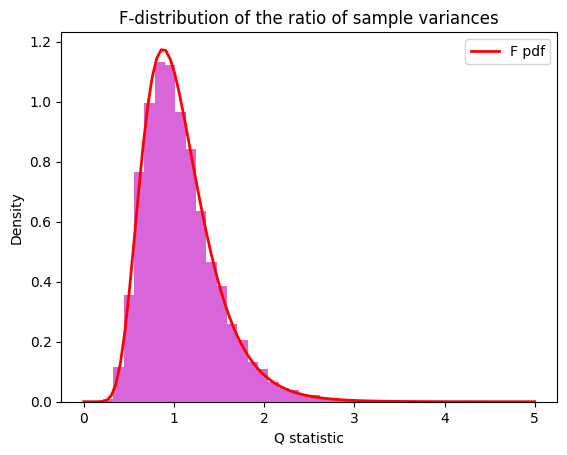

In [ ]:

Q_stats = np.zeros(sim_size)
n = 32

for i in range(sim_size):
    X = stats.norm.rvs(size=n)
    Y = stats.norm.rvs(size=n)

    S1_sq = np.var(X, ddof=1)
    S2_sq = np.var(Y, ddof=1)

    Q_stats[i] = S1_sq / S2_sq
    
plt.hist(Q_stats, bins=30, density=True, alpha=0.6, color='m')
x = np.linspace(0, 5, 100)
plt.plot(x, stats.f.pdf(x, dfn=n-1, dfd=n-1), 'r-', lw=2, label='F pdf')
plt.title('F-distribution of the ratio of sample variances')
plt.xlabel('Q statistic')
plt.ylabel('Density')
plt.legend()
plt.show()